# A/B тест: влияние рекламы на конверсию

In [74]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, confint_proportions_2indep
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("Marketing_AB.csv", index_col=0)
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


## Структура данных

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 27.5+ MB


In [77]:
df.shape

(588101, 6)

In [78]:
summary = df.groupby("test group")["converted"].agg(users="count", conversions="sum", rate="mean")
summary

,users,conversions,rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [79]:
n_ad, n_psa = summary.loc["ad", "users"], summary.loc["psa", "users"]
c_ad, c_psa = summary.loc["ad", "conversions"], summary.loc["psa", "conversions"]

## Гипотеза

- **H0**: конверсия в группе `ad` равна конверсии в группе `psa` ($p_{ad} = p_{psa}$)
- **H1**: конверсии различаются ($p_{ad} \neq p_{psa}$)

Уровень значимости $\alpha = 0.05$.

In [80]:
alpha = 0.05

## Z-тест для проверки гипотезы

In [81]:
count=[c_ad, c_psa]
nobs=[n_ad, n_psa]
z_stat, p_value=proportions_ztest(count, nobs, alternative="two-sided")
print(f"Z-test={z_stat:.2f}, p-value={p_value:.2e}")

Z-test=7.37, p-value=1.71e-13


## Доверительные интервалы

In [ ]:
ci_ad=proportion_confint(c_ad, n_ad, alpha=alpha, method="normal")
ci_psa=proportion_confint(c_psa, n_psa, alpha=alpha, method="normal")
p_ad, p_psa=c_ad / n_ad, c_psa / n_psa
diff=p_ad-p_psa
ci_diff=confint_proportions_2indep(c_ad, n_ad, c_psa, n_psa, method="wald", alpha=alpha)
lift=diff/p_psa*100
print(f"Конверсия ad:{p_ad:.4%}  (95% CI:{ci_ad[0]:.4%}-{ci_ad[1]:.4%})")
print(f"Конверсия psa:{p_psa:.4%}  (95% CI:{ci_psa[0]:.4%}-{ci_psa[1]:.4%})")
print(f"Разница(ad-psa):{diff:.4%}  (95% CI:{ci_diff[0]:.4%}-{ci_diff[1]:.4%})")
print(f"Относительный прирост:{lift:.1f}%")

Конверсия ad:2.5547%  (95% CI:2.5135%-2.5958%)
Конверсия psa:1.7854%  (95% CI:1.6162%-1.9546%)
Разница(ad-psa):0.7692%  (95% CI:0.5951%-0.9434%)
Относительный прирост:43.1%


## Вывод 
### Заключение по A/B тесту:
**Стат.вывод:** Полученное значение $p\text{-value} \approx 1.7 \times 10^{-13}$, что меньше критического уровня $\alpha = 0.05$. Отвергаем нулевую гипотезу. Показ рекламы увеличил конверсию с 1.78% до 2.55%. Относительный прирост составил **+43.09%**. Доверительный интервал для разности долей $[0.60\%, 0.94\%]$, разница статистически значима.

# Дополнительный анализ
## Проверка зависимости конверсии от частоты показов (Проверка гипотезы об усталость от рекламы)

Сама гипотеза: С ростом числа показов рекламы пользователю (Total Ads) наступает эффект усталости(насыщения), и конверсия должна перестать увеличиваться, либо даже снижаться.

In [83]:
bins = [0, 5, 10, 20, 30, 45, 60, 100, np.inf]
labels = ["1-5", "6-10", "11-20", "21-30", "31-45", "46-60", "61-100", "101+"]
fatigue = (
    df[df["test group"] == "ad"]
    .assign(freq_bucket=lambda x: pd.cut(x["total ads"], bins=bins, labels=labels))
    .groupby("freq_bucket", observed=True)["converted"]
    .agg(users="count", conversions="sum", rate="mean")
)
fatigue

,users,conversions,rate
freq_bucket,,,
1-5,169962,427,0.002512
6-10,79537,386,0.004853
11-20,123334,1036,0.008400
21-30,66150,1177,0.017793
31-45,49128,1815,0.036944
46-60,25342,1911,0.075408
61-100,29070,3892,0.133884
101+,22054,3779,0.171352


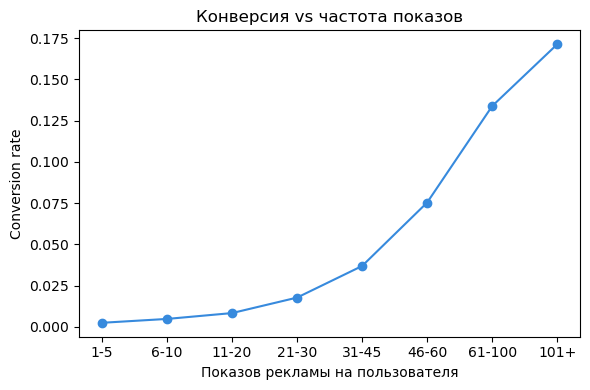

In [84]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fatigue.index.astype(str), fatigue["rate"], marker="o", color="#378ADD")
ax.set_xlabel("Показов рекламы на пользователя")
ax.set_ylabel("Conversion rate")
ax.set_title("Конверсия vs частота показов")
plt.tight_layout()
plt.show()

**Наблюдение:** Конверсия монотонно растёт с частотой показов — усталости от рекламы нет.


Конверсия растёт вместе с частотой показов, но это не значит, что реклама "работает лучше".
Логично, что чем больше рекламы видит пользователей, тем он, вероятнее всего, дольше проводит времени на сайте: это и есть упущенная переменная, которая вызывает эндогенность. Число показов не причина конверсии, а следствие 
проведенного на сайте времени: кто дольше сидит на сайте, тот и увидит больше баннеров.

К тому же, датасет составлен из синтетических данных с Kaggle, так что проверка данной гипотезы - просто для тогоЮ чтобы "показать", что умею.

## Оценка чистого экономического эффекта (Incremental Impact)

Сколько конверсий в группе `ad` — это заслуга рекламы, а не то, что произошло бы само собой.

In [86]:
expected_conversions_no_ads = p_psa * n_ad
incremental_conversions = c_ad - expected_conversions_no_ads
incremental_share = incremental_conversions / c_ad

print(f"Конверсий в группе ad, если бы реклама не сработала (базовая линия psa): {expected_conversions_no_ads:.0f}")
print(f"Фактических конверсий в группе ad: {c_ad}")
print(f"Добавочная конверсии (заслуга рекламы): {incremental_conversions:.0f}")
print(f"Доля конверсий в ad, объяснённая рекламой: {incremental_share:.1%}")

Конверсий в группе ad, если бы реклама не сработала (базовая линия psa): 10080
Фактических конверсий в группе ad: 14423
Добавочная конверсии (заслуга рекламы): 4343
Доля конверсий в ad, объяснённая рекламой: 30.1%
